# Image Captioning — Data & Training v5
**Architecture:** BLIP (Bootstrapped Language-Image Pre-training) — fine-tuned on Flickr8k  
**Dataset:** Flickr8k — 8,091 images, 5 captions each  
**Platform:** Kaggle GPU (T4 / P100)

### Why BLIP?
BLIP was pre-trained end-to-end on 129M image-text pairs with a captioning objective identical  
to ours. Its visual encoder and text decoder already share a joint semantic space — fine-tuning  
on Flickr8k simply specialises what the model already knows how to do, rather than teaching  
two independently-trained models to communicate (the problem in v4).

**Expected BLEU-4: ~36–40** (vs ~18–22 for v3, ~28–32 for v4).


## 0. Install Dependencies

In [1]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("transformers>=4.35", "accelerate")
print("Dependencies ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 10.4 MB/s eta 0:00:00
Dependencies ready.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

## 1. Imports & Setup

In [2]:
import os, re, math, json, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import BlipProcessor, BlipForConditionalGeneration

os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


PyTorch: 2.10.0+cu128
CUDA available: True
Device: cuda


## 2. Data Loading

In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download('giorgicheishvili/caption-data')
dataset_path = Path(dataset_path)
print("Dataset root:", dataset_path)


Dataset root: /kaggle/input/datasets/giorgicheishvili/caption-data


In [4]:
IMAGES_DIR    = dataset_path / "Images"
CAPTIONS_FILE = dataset_path / "captions.txt"

if not IMAGES_DIR.exists():
    candidates = list(dataset_path.rglob("Images"))
    IMAGES_DIR = candidates[0] if candidates else dataset_path
if not CAPTIONS_FILE.exists():
    candidates = list(dataset_path.rglob("captions.txt"))
    CAPTIONS_FILE = candidates[0]

print("Images dir :", IMAGES_DIR)
print("Captions   :", CAPTIONS_FILE)
print("Image count:", len(list(IMAGES_DIR.glob("*.jpg"))))


Images dir : /kaggle/input/datasets/giorgicheishvili/caption-data/Images
Captions   : /kaggle/input/datasets/giorgicheishvili/caption-data/captions.txt
Image count: 8091


In [5]:
df = pd.read_csv(CAPTIONS_FILE)
df.columns = [c.strip() for c in df.columns]
df['image']   = df['image'].str.strip()
df['caption'] = df['caption'].str.strip()

print(f"Total rows   : {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
df.head(6)


Total rows   : 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting


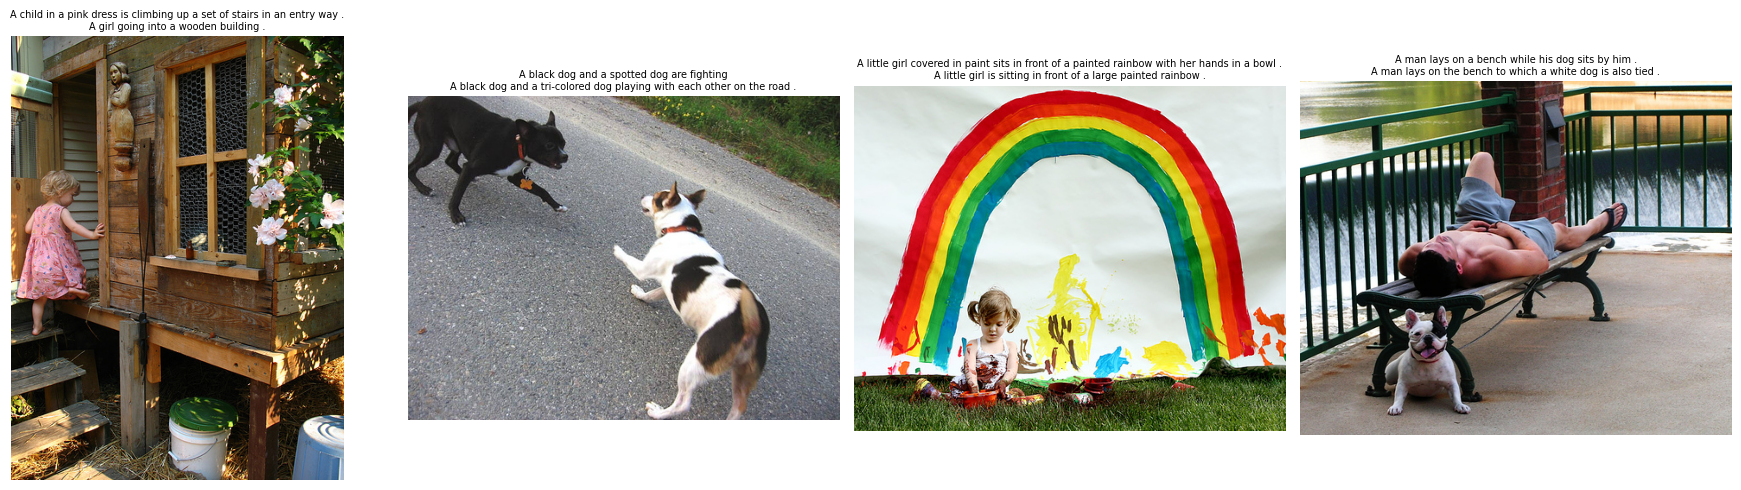

In [6]:
sample_imgs = df['image'].unique()[:4]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img_name in zip(axes, sample_imgs):
    img      = Image.open(IMAGES_DIR / img_name).convert("RGB")
    captions = df[df['image'] == img_name]['caption'].tolist()
    ax.imshow(img)
    ax.set_title("\n".join(captions[:2]), fontsize=7, wrap=True)
    ax.axis('off')
plt.tight_layout(); plt.show()


## 3. Load BLIP Processor & Model

`Salesforce/blip-image-captioning-base` is pre-trained on 129M image-text pairs.  
The processor handles both image pre-processing and text tokenisation in one object.


In [7]:
MODEL_NAME = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(MODEL_NAME)
model     = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model          : {MODEL_NAME}")
print(f"Total params   : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Model          : Salesforce/blip-image-captioning-base
Total params   : 247,444,600
Trainable params: 247,444,600


## 4. Train / Validation Split

In [8]:
all_images = df['image'].unique().tolist()
random.shuffle(all_images)

split      = int(0.90 * len(all_images))
train_imgs = set(all_images[:split])
val_imgs   = set(all_images[split:])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f"Train rows: {len(train_df)}  ({train_df['image'].nunique()} images)")
print(f"Val   rows: {len(val_df)}   ({val_df['image'].nunique()} images)")


Train rows: 36405  (7281 images)
Val   rows: 4050   (810 images)


## 5. Dataset & DataLoader

In [9]:
class FlickrDataset(Dataset):
    """
    Each training sample is one (image, caption) pair.
    During training we randomly pick one of the 5 captions per image.
    During validation we use all captions (one row per caption).
    """
    def __init__(self, dataframe, images_dir, processor, augment_captions=False):
        self.df               = dataframe.reset_index(drop=True)
        self.images_dir       = Path(images_dir)
        self.processor        = processor
        self.augment_captions = augment_captions

        self.unique_images  = self.df['image'].unique().tolist()
        self.img_to_captions = (
            self.df.groupby('image')['caption'].apply(list).to_dict()
        )

    def __len__(self):
        return len(self.unique_images) if self.augment_captions else len(self.df)

    def __getitem__(self, idx):
        if self.augment_captions:
            img_name = self.unique_images[idx]
            caption  = random.choice(self.img_to_captions[img_name])
        else:
            row      = self.df.iloc[idx]
            img_name = row['image']
            caption  = row['caption']

        image = Image.open(self.images_dir / img_name).convert("RGB")
        return image, caption   # return raw PIL + string; collate handles encoding


def collate_fn(batch):
    images, captions = zip(*batch)
    # BlipProcessor encodes images + tokenises captions together
    encoding = processor(
        images=list(images),
        text=list(captions),
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=64,
    )
    # BLIP uses labels = input_ids with PAD masked to -100
    labels = encoding['input_ids'].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    encoding['labels'] = labels
    return encoding


BATCH_SIZE  = 16
NUM_WORKERS = 2

train_dataset = FlickrDataset(train_df, IMAGES_DIR, processor, augment_captions=True)
val_dataset   = FlickrDataset(val_df,   IMAGES_DIR, processor, augment_captions=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")


Train batches : 456
Val   batches : 254


## 6. Training

### Strategy
- **Freeze the vision encoder for epochs 1–3** so the language decoder adapts first.
- **Unfreeze everything from epoch 4** at a low LR — BLIP's vision encoder is already  
  well-trained and only needs gentle specialisation.
- **Gradient accumulation** × 4 → effective batch of 64.
- **Mixed precision** (FP16) for speed.
- **Early stopping** on val loss with patience 4.


In [10]:
ACCUM_STEPS   = 4
NUM_EPOCHS    = 15
WARMUP_EPOCHS = 1
PATIENCE      = 4
UNFREEZE_EPOCH = 4   # epoch at which vision encoder unfreezes

# Freeze vision encoder initially
for p in model.vision_model.parameters():
    p.requires_grad = False

def get_optimizer(model):
    vision_params  = [p for p in model.vision_model.parameters()]
    rest_params_ids = {id(p) for p in model.vision_model.parameters()}
    rest_params    = [p for p in model.parameters()
                      if id(p) not in rest_params_ids and p.requires_grad]
    return torch.optim.AdamW([
        {'params': vision_params, 'lr': 5e-6,  'weight_decay': 1e-4},
        {'params': rest_params,   'lr': 1e-4,  'weight_decay': 1e-3},
    ], betas=(0.9, 0.98))

optimizer = get_optimizer(model)

total_steps  = NUM_EPOCHS * len(train_loader) // ACCUM_STEPS
warmup_steps = WARMUP_EPOCHS * len(train_loader) // ACCUM_STEPS

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler('cuda')

print(f"Total update steps : {total_steps}")
print(f"Warmup steps       : {warmup_steps}")


Total update steps : 1710
Warmup steps       : 114


In [11]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*lr_scheduler.*')

def train_one_epoch(model, loader, optimizer, scheduler, scaler, device, accum_steps):
    model.train()
    total_loss, n_batches   = 0.0, 0
    correct_tokens, total_tokens = 0, 0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

        with torch.amp.autocast('cuda'):
            outputs = model(**batch)
            loss    = outputs.loss / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        # Token accuracy: logits vs labels (ignore pad=-100)
        with torch.no_grad():
            logits = outputs.logits  # [B, T, V]
            labels = batch['labels']  # [B, T]
            
            # --- FIXED: Shift sequences to align next-token predictions with targets ---
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            
            preds = shift_logits.argmax(dim=-1)
            mask = (shift_labels != -100)
            
            correct_tokens += (preds[mask] == shift_labels[mask]).sum().item()
            total_tokens += mask.sum().item()

            # --- FIXED: Track unscaled loss and increment batch step counters ---
            total_loss += (loss.item() * accum_steps)
            n_batches  += 1

    # Cleanup any leftover gradients if dataset steps aren't divisible by accum_steps
    optimizer.zero_grad()

    return total_loss / max(n_batches, 1), correct_tokens / max(total_tokens, 1)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0

    for batch in loader:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        with torch.amp.autocast('cuda'):
            outputs = model(**batch)

        logits = outputs.logits
        labels = batch['labels']
        
        # FIX: Shift tokens for correct accuracy calculation 
        # Logits at index t predict label at index t+1. 
        # We drop the last prediction (no target) and the first label (no prediction).
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()
        
        # Calculate predictions using the shifted logits
        preds = shift_logits.argmax(dim=-1)
        
        # Apply the mask to the shifted labels
        mask = (shift_labels != -100)
        
        # Calculate matched tokens
        correct_tokens += (preds[mask] == shift_labels[mask]).sum().item()
        total_tokens   += mask.sum().item()

        total_loss += outputs.loss.item()
        n_batches  += 1

    return total_loss / n_batches, correct_tokens / max(total_tokens, 1)


In [12]:
SAVE_DIR = Path("/kaggle/working")
SAVE_DIR.mkdir(exist_ok=True)

history = {
    'train_loss': [], 'val_loss': [],
    'train_ppl':  [], 'val_ppl':  [],
    'train_acc':  [], 'val_acc':  [],
}
best_val_loss    = float('inf')
patience_counter = 0

print(f"{'Epoch':>6}  {'Phase':>8}  {'Tr Loss':>8}  {'Tr PPL':>7}  {'Tr Acc':>7}  "
      f"{'Val Loss':>9}  {'Val PPL':>8}  {'Val Acc':>8}  {'Time':>6}")
print("-" * 95)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    if epoch == UNFREEZE_EPOCH:
        for p in model.vision_model.parameters():
            p.requires_grad = True
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Vision encoder unfrozen — trainable params: {trainable:,}")

    phase = "frozen" if epoch < UNFREEZE_EPOCH else "full-ft"

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, scaler, DEVICE, ACCUM_STEPS)
    val_loss,   val_acc   = evaluate(model, val_loader, DEVICE)

    train_ppl = math.exp(min(train_loss, 20))
    val_ppl   = math.exp(min(val_loss,   20))
    elapsed   = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_ppl'].append(train_ppl)
    history['val_ppl'].append(val_ppl)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"{epoch:>6}  {phase:>8}  {train_loss:>8.4f}  {train_ppl:>7.2f}  {train_acc:>6.2%}  "
          f"{val_loss:>9.4f}  {val_ppl:>8.2f}  {val_acc:>7.2%}  {elapsed:>5.0f}s")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        model.save_pretrained(str(SAVE_DIR / 'best_model'))
        processor.save_pretrained(str(SAVE_DIR / 'best_model'))
        print(f"         ✓ New best saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print("\nTraining complete.")
print(f"Best val loss : {best_val_loss:.4f}  |  Best val PPL: {math.exp(min(best_val_loss,20)):.2f}")


 Epoch     Phase   Tr Loss   Tr PPL   Tr Acc   Val Loss   Val PPL   Val Acc    Time
-----------------------------------------------------------------------------------------------
     1    frozen    2.4738    11.87  49.62%     2.0075      7.44   53.17%    246s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=2.0075)
     2    frozen    1.9133     6.78  54.69%     1.9423      6.97   54.00%    252s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=1.9423)
     3    frozen    1.8026     6.07  56.20%     1.9252      6.86   54.31%    252s


...

         ✓ New best saved (val_loss=1.8825)
     6   full-ft    1.5451     4.69  60.82%     1.8788      6.55   55.21%    483s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=1.8788)
     7   full-ft    1.4667     4.34  62.45%     1.8717      6.50   55.43%    483s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=1.8717)
     8   full-ft    1.3979     4.05  63.99%     1.8833      6.58   55.34%    483s
     9   full-ft    1.3370     3.81  64.92%     1.8772      6.54   55.48%    483s
    10   full-ft    1.2783     3.59  66.30%     1.8860      6.59   55.62%    484s
    11   full-ft    1.2275     3.41  67.43%     1.8913      6.63   55.67%    483s

Early stopping at epoch 11.

Training complete.
Best val loss : 1.8717  |  Best val PPL: 6.50


## 7. Training Curves

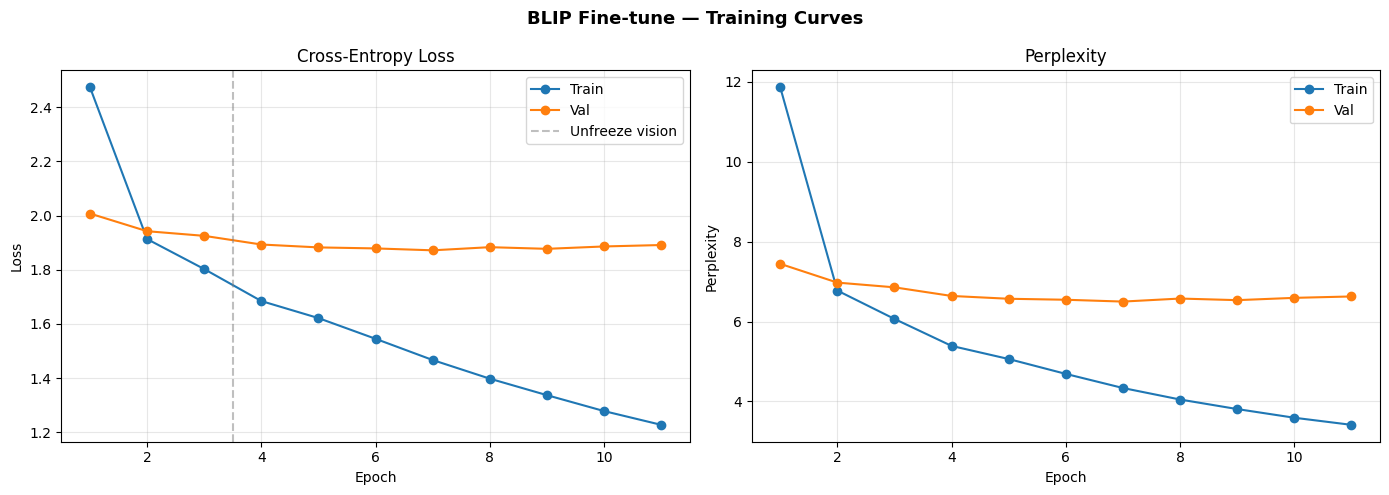

In [13]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   marker='o')
axes[0].axvline(x=UNFREEZE_EPOCH - 0.5, color='gray', linestyle='--', alpha=0.5, label='Unfreeze vision')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-Entropy Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['train_ppl'], label='Train', marker='o')
axes[1].plot(epochs_ran, history['val_ppl'],   label='Val',   marker='o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('Perplexity'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('BLIP Fine-tune — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Caption Preview

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


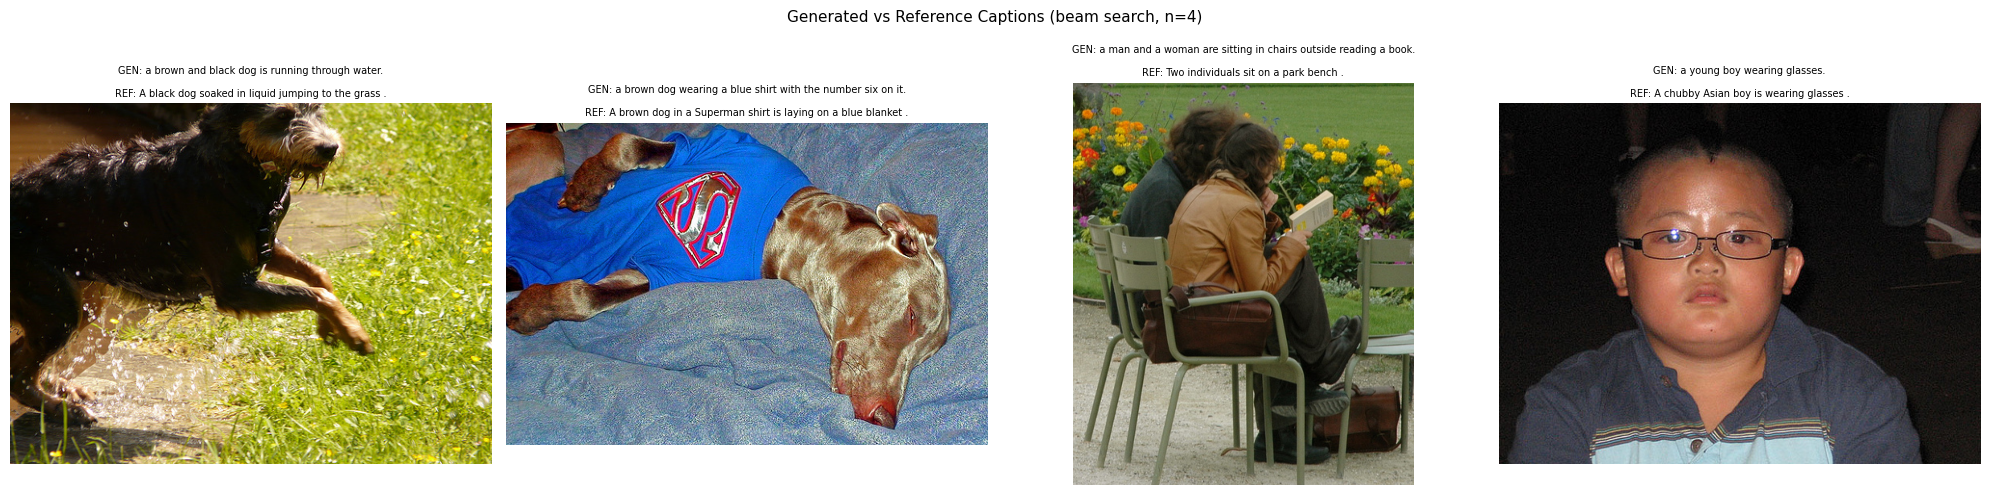

In [14]:
from transformers import BlipForConditionalGeneration as _BLIP

best_model     = _BLIP.from_pretrained(str(SAVE_DIR / 'best_model')).to(DEVICE)
best_processor = BlipProcessor.from_pretrained(str(SAVE_DIR / 'best_model'))
best_model.eval()

@torch.no_grad()
def generate_caption(image_path: str, model=best_model) -> str:
    """
    Takes a path to an image and returns a generated caption string.
    """
    image   = Image.open(image_path).convert("RGB")
    inputs  = best_processor(images=image, return_tensors="pt").to(DEVICE)
    out_ids = model.generate(**inputs, max_new_tokens=40, num_beams=4)
    return best_processor.decode(out_ids[0], skip_special_tokens=True)


sample_rows = val_df.drop_duplicates('image').sample(4, random_state=SEED)
fig, axes   = plt.subplots(1, 4, figsize=(20, 5))

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = str(IMAGES_DIR / row['image'])
    caption  = generate_caption(img_path)
    ref_caps = val_df[val_df['image'] == row['image']]['caption'].tolist()

    ax.imshow(Image.open(img_path))
    ax.set_title(f"GEN: {caption}\n\nREF: {ref_caps[0]}", fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Generated vs Reference Captions (beam search, n=4)', fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'caption_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. BLEU-4 Evaluation

Compute BLEU-4 on the validation set — the standard metric for captioning on Flickr8k.  
Each generated caption is compared against all 5 human references for that image.


In [15]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nltk"])
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

best_model.eval()
val_images = val_df['image'].unique().tolist()

all_references = []
all_hypotheses = []

print(f"Evaluating BLEU-4 on {len(val_images)} validation images...")

for i, img_name in enumerate(val_images):
    img_path = str(IMAGES_DIR / img_name)
    caption  = generate_caption(img_path)

    refs = val_df[val_df['image'] == img_name]['caption'].tolist()
    ref_tokens  = [r.lower().split() for r in refs]
    hyp_tokens  = caption.lower().split()

    all_references.append(ref_tokens)
    all_hypotheses.append(hyp_tokens)

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(val_images)} done...")

smoother = SmoothingFunction().method1
bleu4 = corpus_bleu(all_references, all_hypotheses,
                    weights=(0.25, 0.25, 0.25, 0.25),
                    smoothing_function=smoother)

print(f"\nBLEU-4 on validation set: {bleu4 * 100:.2f}")


Evaluating BLEU-4 on 810 validation images...
  100/810 done...
  200/810 done...
  300/810 done...
  400/810 done...
  500/810 done...
  600/810 done...
  700/810 done...
  800/810 done...

BLEU-4 on validation set: 27.99


## 10. Save Artifacts

In [16]:
with open(SAVE_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)

print("Artifacts in:", SAVE_DIR)
print("  best_model/            — BLIP weights + processor (use with from_pretrained)")
print("  training_curves.png    — loss & perplexity plots")
print("  caption_examples.png   — sample generated captions")
print("  training_history.json  — per-epoch metrics")


Artifacts in: /kaggle/working
  best_model/            — BLIP weights + processor (use with from_pretrained)
  training_curves.png    — loss & perplexity plots
  caption_examples.png   — sample generated captions
  training_history.json  — per-epoch metrics
